In [1]:
#import necessary libraries for EDA
import pandas as pd

#load the CSV file and examine its structure for the EDA process.
df_new = pd.read_csv('Suicide_Detection.csv')

# Display the basic information of the dataset
df_new.info(), df_new.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  232074 non-null  int64 
 1   text        232074 non-null  object
 2   class       232074 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.3+ MB


(None,
    Unnamed: 0                                               text        class
 0           2  Ex Wife Threatening SuicideRecently I left my ...      suicide
 1           3  Am I weird I don't get affected by compliments...  non-suicide
 2           4  Finally 2020 is almost over... So I can never ...  non-suicide
 3           8          i need helpjust help me im crying so hard      suicide
 4           9  I’m so lostHello, my name is Adam (16) and I’v...      suicide)

In [8]:
# Dropping the unnecessary 'Unnamed: 0' column
df_cleaned = df_new.drop(columns=['Unnamed: 0'])

# Checking for missing data
missing_values_new = df_cleaned.isnull().sum()

# Visualizing the distribution of the 'class' column
class_distribution_new = df_cleaned['class'].value_counts()

# Creating a new column for text length and visualizing its distribution
df_cleaned['text_length'] = df_cleaned['text'].apply(len)

# Displaying missing values, class distribution, and descriptive statistics for text length
missing_values_new, class_distribution_new, df_cleaned['text_length'].describe()


(text     0
 class    0
 dtype: int64,
 class
 suicide        116037
 non-suicide    116037
 Name: count, dtype: int64,
 count    232074.000000
 mean        689.639736
 std        1156.334007
 min           3.000000
 25%         138.000000
 50%         315.000000
 75%         801.000000
 max       40297.000000
 Name: text_length, dtype: float64)

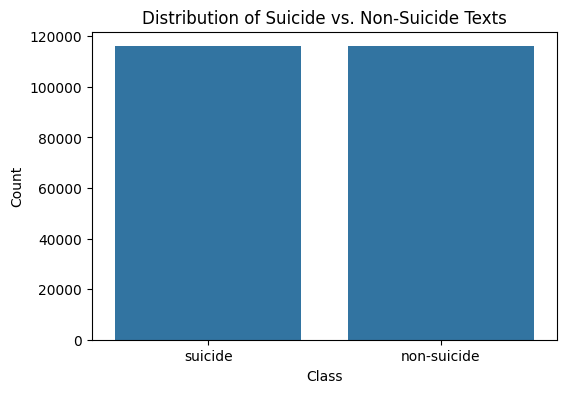

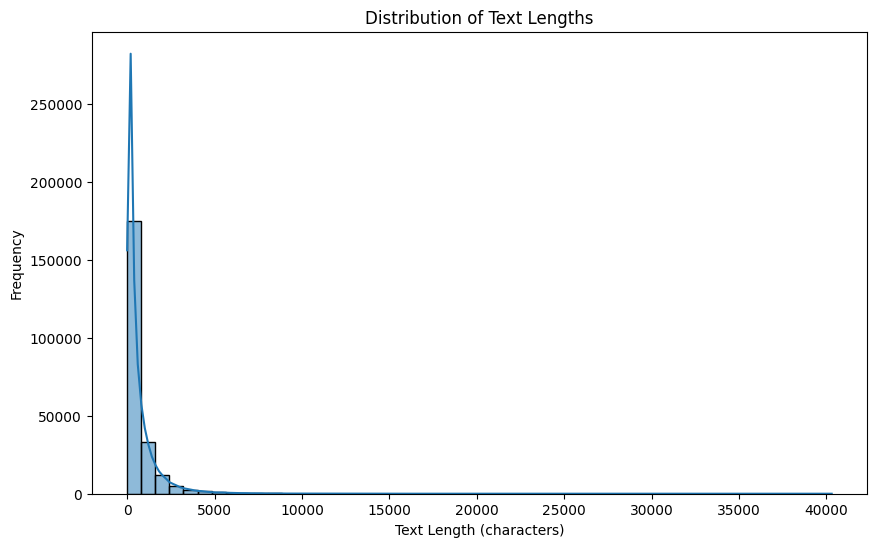

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of 'class' column
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned_new, x='class')
plt.title('Distribution of Suicide vs. Non-Suicide Texts')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Plotting the distribution of text length
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned_new['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.show()


In [10]:
import string
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

In [11]:
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(f'[{string.punctuation}]', '', text)  # Remove punctuation
    return text

In [13]:
df_cleaned['processed_text'] = df_cleaned['text'].apply(preprocess_text)

def get_words(corpus, n=None):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

words_overall = get_words(df_cleaned['processed_text'], 10)
print("Top 10 Words Overall:", words_overall)

words_suicide = get_words(df_cleaned[df_cleaned['class'] == 'suicide']['processed_text'], 10)
print("Top 10 Words in Suicide Texts:", words_suicide)

words_non_suicide = get_words(df_cleaned[df_cleaned['class'] == 'non-suicide']['processed_text'], 10)
print("Top 10 Words in Non-Suicide Texts:", words_non_suicide)


def get_ngrams(corpus, n=None, ngram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    ngrams_freq = [(ngram, sum_words[0, idx]) for ngram, idx in vec.vocabulary_.items()]
    ngrams_freq = sorted(ngrams_freq, key=lambda x: x[1], reverse=True)
    return ngrams_freq[:n]


bigrams_overall = get_ngrams(df_cleaned['text'], 10, ngram_range=(2, 2))
print("Top 10 Bi-grams Overall:", bigrams_overall)

bigrams_suicide = get_ngrams(df_cleaned[df_cleaned['class'] == 'suicide']['text'], 10, ngram_range=(2, 2))
print("Top 10 Bi-grams in Suicide Texts:", bigrams_suicide)

bigrams_non_suicide = get_ngrams(df_cleaned[df_cleaned['class'] == 'non-suicide']['text'], 10, ngram_range=(2, 2))
print("Top 10 Bi-grams in Non-Suicide Texts:", bigrams_non_suicide)

trigrams_overall = get_ngrams(df_cleaned['text'], 10, ngram_range=(3, 3))
print("Top 10 Tri-grams Overall:", trigrams_overall)

trigrams_suicide = get_ngrams(df_cleaned[df_cleaned['class'] == 'suicide']['text'], 10, ngram_range=(3, 3))
print("Top 10 Tri-grams in Suicide Texts:", trigrams_suicide)

trigrams_non_suicide = get_ngrams(df_cleaned[df_cleaned['class'] == 'non-suicide']['text'], 10, ngram_range=(3, 3))
print("Top 10 Tri-grams in Non-Suicide Texts:", trigrams_non_suicide)

def get_bag_of_words(corpus):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return words_freq

# Bag of Words overall
bow_overall = get_bag_of_words(df_cleaned['text'])
print("Bag of Words Overall (first 10):", bow_overall[:10])

# Bag of Words in suicide texts
bow_suicide = get_bag_of_words(df_cleaned[df_cleaned['class'] == 'suicide']['text'])
print("Bag of Words in Suicide Texts (first 10):", bow_suicide[:10])

# Bag of Words in non-suicide texts
bow_non_suicide = get_bag_of_words(df_cleaned[df_cleaned['class'] == 'non-suicide']['text'])
print("Bag of Words in Non-Suicide Texts (first 10):", bow_non_suicide[:10])

Top 10 Words Overall: [('just', 257024), ('im', 252989), ('like', 181341), ('dont', 161875), ('want', 148786), ('know', 131102), ('feel', 122494), ('life', 120316), ('people', 93764), ('time', 86324)]
Top 10 Words in Suicide Texts: [('im', 213452), ('just', 203484), ('dont', 139930), ('like', 131019), ('want', 128288), ('life', 110851), ('feel', 107943), ('know', 106347), ('ive', 75374), ('people', 71898)]
Top 10 Words in Non-Suicide Texts: [('filler', 54166), ('just', 53540), ('like', 50322), ('im', 39537), ('know', 24755), ('dont', 21945), ('people', 21866), ('want', 20498), ('fuck', 19514), ('day', 18430)]
Top 10 Bi-grams Overall: [('filler filler', 50328), ('don know', 46363), ('feel like', 44996), ('don want', 35544), ('just want', 22807), ('want die', 13244), ('fuck fuck', 13116), ('just don', 10874), ('don think', 10220), ('amp x200b', 7760)]
Top 10 Bi-grams in Suicide Texts: [('don know', 40306), ('feel like', 39982), ('don want', 32744), ('just want', 20450), ('want die', 1292